In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ydata_profiling import ProfileReport
import pickle
import random
import itertools

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 50

data_folder = "../data/"
images_folder = "../../images/"
pipelines_folder = "../pipelines/"
df_total = pd.read_csv(os.path.join(data_folder, 'items_phase_1.csv'))
df_train = pd.read_csv(os.path.join(data_folder, 'items_train.csv'))
df_task_1 = pd.read_csv(os.path.join(data_folder, 'task_1.csv'))

# Notebook `items_phase_1.csv`

In [2]:
# profile = ProfileReport(df_total, title="items_phase_1", explorative=True)
# profile.to_notebook_iframe()

In [3]:
print("Length of dataset:", len(df_total))

Length of dataset: 199835


In [4]:
df_total.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo
103955,1171738,1449.00,"230,806",['1'],[1557256],Sneakersy DC,DC Sneakersy COURT GRAFFIK DC01662061 Černá,cz
175318,578982,44.99,"6455,1443396",['1'],NaN,Šľapky Roxy,Roxy Šľapky HY62277-5 Béžová,sk


## Key takeaway
- missingy se musi resit u:
    - description (3%)
    - brandEditionTagId (99.8%) - to je asi target?
    - colorTagIdsString (3.1%)
---
# Notebook `task_1.csv`
- kazdy radek je jedna skupina se sloupci item - item4(to jsou id do items_phase_1.csv - itemId)
- Kazdy 

In [5]:
print("Length of dataset:", len(df_task_1))

Length of dataset: 15000


In [6]:
# profile = ProfileReport(df_task_1, title="task_1", explorative=True)
# profile.to_notebook_iframe()

In [7]:
df_task_1.head()

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761


---
# Dataset `items_train.csv`
- obsahuje toho min, vim ze ma stejny hodnoty v departmentIds


In [8]:
print("Total records:", len(df_train))
print("Total null values:\n", df_train.isnull().sum())

Total records: 928234
Total null values:
 itemId                    0
price                     0
colorTagIdsString     27834
departmentIds             0
brandEditionTagId    925518
title                     0
description           35473
geo                       0
label                     0
dtype: int64


In [9]:
df_train.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo,label
678234,343832,27.95,"771,772",['11'],NaN,3 bokseršortu pāru komplekts Cristiano Ronaldo...,Cristiano Ronaldo CR7 3 bokseršortu pāru kompl...,lv,219565
662074,620289,57.99,230,['1'],NaN,Čevlji brez vezalk Lasocki,Lasocki Čevlji brez vezalk WB-GIULIA-22 Črna,si,220367


In [10]:
# profile = ProfileReport(df_train, title="task_1", explorative=True)
# profile.to_notebook_iframe()


--- 
## Ukazka obrazku + kontrola zda mame vsechny

=== Ukazka ===
itemId                                        225269
price                                          85.95
colorTagIdsString                               6460
departmentIds                                  ['1']
brandEditionTagId                                NaN
title                                   Šľapky Guess
description          Šľapky Guess FLJRLL LEA19 Hnedá
geo                                               sk
label                                          38980
Name: 79, dtype: object



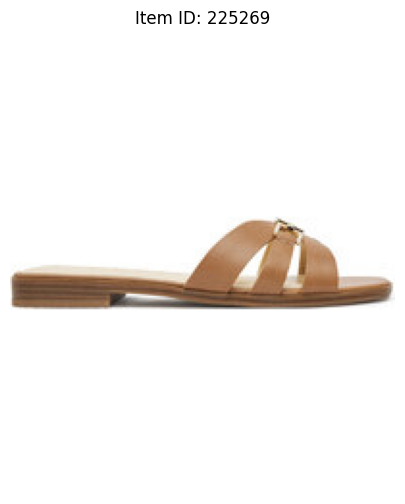

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

first_row = df_train.iloc[79] 
item_id = first_row['itemId']

print("=== Ukazka ===")
print(first_row)
print("===============================\n")

img_path = os.path.join(images_folder, f"{item_id}.jpg")

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Item ID: {item_id}")
plt.show()

In [12]:
import os
import pandas as pd

def find_missing_images(df, images_folder, item_col='itemId'):
    print("🔍 Analyzuji dataset a složku s obrázky...")
    
    expected_ids = set(df[item_col].astype(str))
    print(f"📊 Tabulka vyžaduje: {len(expected_ids)} unikátních obrázků.")
    
    try:
        available_files = [f[:-4] for f in os.listdir(images_folder) if f.endswith('.jpg')]
        available_ids = set(available_files)
        print(f"📂 Na disku nalezeno: {len(available_ids)} .jpg souborů.")
    except FileNotFoundError:
        print(f"❌ Chyba: Složka '{images_folder}' neexistuje!")
        return []

    missing_ids = expected_ids - available_ids
    
    if len(missing_ids) == 0:
        print("🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.")
    else:
        print(f"⚠️ POZOR: Chybí přesně {len(missing_ids)} obrázků!")
        print(f"Ukázka chybějících ID: {list(missing_ids)[:5]}")
        
    return list(missing_ids)

chybejici_obrazky = find_missing_images(df_total, images_folder)
chybejici_obrazky = find_missing_images(df_train, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 199835 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


---
# Vycisteni dat 
- prevod na spolecnou menu 
- normalizace meny v danem geo uzemi
- doplneni null hodnot
- null ve sloupci `colorTagIdString` muzu nahradit 0 
- `colorTagIdString` a `departmentIds` je potreba roztrhnout - obsahuji vice hodnot oddelenych carkou

## Tvorba preprocessing pipeline

In [13]:
df_total[df_total["brandEditionTagId"] == 0]

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo


In [14]:
df_train.columns

Index(['itemId', 'price', 'colorTagIdsString', 'departmentIds',
       'brandEditionTagId', 'title', 'description', 'geo', 'label'],
      dtype='object')

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from PriceGeoTransformer import PriceGeoTransformer
from DepartmentIdsTransformer import DepartmentIdsCleaner
import numpy as np


input_unknown_cols = ["description","title"]
input_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Unknown")),
])



# Pro textové IDčka (barvy) dáme prázdný string
imput_empty_string_cols = ['colorTagIdsString']
input_empty_string_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="")),
])

imput_zero_cols = ["brandEditionTagId"]
input_zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])


# prevadi na stejny format jako jsou barvy - cisla oddelena carkou 
department_features = ['departmentIds']
department_transformer = Pipeline(steps=[
    ('DepartmentIdsCleaner', DepartmentIdsCleaner())
])

# impute missing geo and convert back to pandas
imputer_step = ColumnTransformer(
    transformers=[
        ('geo_imp', SimpleImputer(strategy='constant', fill_value='<UNK>'), ['geo']),
        ('price_imp', SimpleImputer(strategy='median'), ['price'])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False 
).set_output(transform="pandas")

categorical_features = ['geo',"price"]
categorical_transformer = Pipeline(steps=[
    ("imputer", imputer_step),
    ('PriceGeoTransformer', PriceGeoTransformer())
])


# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('zero', input_zero_transformer, imput_zero_cols),
        ('unknown', input_unknown_transformer, input_unknown_cols),
        ('geo', categorical_transformer, categorical_features),
        ('department', department_transformer, department_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_train_transformed = pipeline.fit_transform(X_train)
df_train_transformed = X_train_transformed.copy()
df_train_transformed['label'] = y_train.values
df_total_transformed = pipeline.transform(df_total)

In [16]:
pickle.dump(pipeline, open(os.path.join(pipelines_folder, 'preprocessing_pipeline.pkl'), 'wb'))

In [17]:
# find_missing_images(df_total_transformed, images_folder)
find_missing_images(df_train_transformed, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


[]

## Příprava pro PyTorch dataset - Vocabulary pro transformaci kategorií
- PyTorch bude použit na vytvoření embeddingů sloupců s více kategorijema a na kategorické sloupce
- PyTorch umí totiž lépe tvořit řídké matice
- Vytvoříme si mappingy pro jednotlivé kategorie...

In [18]:
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager() # vytvori vsechny potrebne mappingy kategorii do ciselnych hodnot
vocab_manager.fit(df_total_transformed)
vocab_manager.save()

## Tvorba embeddingů obrázků

In [19]:
import torch
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image
import os
from tqdm import tqdm # Pro hezký progress bar

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Běžíme na MPS!")
else:
    device = torch.device("cpu")
    print("⚠️ Běžíme na CPU.")

🚀 Běžíme na MPS!


In [20]:
def create_and_save_clip_embeddings(image_dir, item_ids, save_path="clip_embeddings.pt", batch_size=128):
    item_ids = list(item_ids)
    
    model_id = "openai/clip-vit-base-patch32"
    print(f"Načítám model {model_id}...")
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPVisionModel.from_pretrained(model_id).to(device)
    model.eval() # Přepneme do módu vyhodnocování

    embeddings_dict = {}
    valid_ids = []
    images_to_process = []

    print("Připravuji obrázky...")
    
    # processing images
    for i in tqdm(range(0, len(item_ids), batch_size)):
        batch_ids = item_ids[i:i + batch_size]
        batch_images = []
        batch_valid_ids = []

        # Načteme obrázky v dávce
        for item_id in batch_ids:
            img_path = os.path.join(image_dir, f"{item_id}.jpg")
            try:
                img = Image.open(img_path).convert("RGB")
                batch_images.append(img)
                batch_valid_ids.append(str(item_id))
            except Exception:
                print("Missing image for item_id:", item_id)


        if not batch_images:
            continue

        # 4. Provedení samotné extrakce na čipu
        with torch.no_grad(): # Šetří paměť, nechceme počítat gradienty
            inputs = processor(images=batch_images, return_tensors="pt").to(device)
            outputs = model(**inputs)
            image_embeds = outputs.pooler_output 

            # 5. Uložení do slovníku (přesuneme zpět na CPU, ať neplníme GPU paměť)
            image_embeds = image_embeds.cpu()
            for idx, i_id in enumerate(batch_valid_ids):
                embeddings_dict[i_id] = image_embeds[idx]

    print(f"Ukládám {len(embeddings_dict)} embeddingů do {save_path}...")
    torch.save(embeddings_dict, save_path)
    print("Hotovo! 🎉")
    
    return embeddings_dict

In [22]:
df_task_1

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761
...,...,...,...,...,...
14995,155554,524218,1124026,1180971,1245961
14996,2182,142647,528017,744044,966164
14997,360650,831549,941406,1002011,1225666
14998,481664,1021759,1123392,1272187,1283135


In [ ]:
import os
import torch

os.environ["HF_HUB_OFFLINE"] = "1"
df_total
print("Připravuji CLIP embeddingy...")
item_ids_list = df_train_transformed['itemId'].unique().tolist()
item_ids_total = df_total_transformed['itemId'].unique().tolist()
item_ids_list = list(set(item_ids_list) | set(item_ids_total))
embeddings_path = "clip_embeddings.pt"

# Chytrá kontrola: nebudeme to počítat znovu, pokud už to máme!
if os.path.exists(embeddings_path):
    print("Načítám hotové embeddingy z disku (blesková akce)...")
    clip_embeddings_dict = torch.load(embeddings_path)
else:
    print("Soubor nenalezen. Žhavím Apple M4 Pro a jdu počítat z obrázků...")
    # Tady zavoláme tu funkci z minula!
    clip_embeddings_dict = create_and_save_clip_embeddings(
        image_dir=images_folder,
        item_ids=item_ids_list, 
        save_path=embeddings_path, 
        batch_size=128 # M4 Pro zvládne velké batche s přehledem
    )

print(f"Máme {len(clip_embeddings_dict)} vektorů obrázků!")

Připravuji CLIP embeddingy...
Soubor nenalezen. Žhavím Apple M4 Pro a jdu počítat z obrázků...
Načítám model openai/clip-vit-base-patch32...


## PyTorch Dataset


--- 


## Tvorba siamese datasetu
- dataset obsahuje páry z originálního datasetu teré mají jako label 1 pokud mají stejné labely uvitř páru, jinak 0
- create_balanced_pairs jich vytvori tolik aby byly vyvazene labely 

# Training Pairs — Data Quality Analysis

**Goal:** understand why the model confuses "similar but different" items with duplicates,
and how to generate better negative examples so the next training run learns sharper boundaries.

Key questions:
1. What do the current negative pairs look like — are they truly hard?
2. What structure do true duplicate pairs have (geo, price, dept)?
3. What categories of "hard negatives" are missing?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

train_pairs = pd.read_csv("train_pairs_hard_negatives.csv")
df_train    = pd.read_csv("../data/items_train.csv")

pos = train_pairs[train_pairs.is_duplicate == 1.0]
neg = train_pairs[train_pairs.is_duplicate == 0.0]

print(f"Total pairs:  {len(train_pairs):,}")
print(f"  Positives:  {len(pos):,}  ({len(pos)/len(train_pairs):.1%})")
print(f"  Negatives:  {len(neg):,}  ({len(neg)/len(train_pairs):.1%})")
print(f"\nUnique items in pairs: {pd.concat([train_pairs.item_id_1, train_pairs.item_id_2]).nunique():,}")
print(f"Total items in train:  {len(df_train):,}")

label_counts = df_train.label.value_counts()
print(f"\nLabel distribution (how many items share the same product label):")
print(f"  Singleton labels (1 item):  {(label_counts==1).sum():,}")
print(f"  2 items:                    {(label_counts==2).sum():,}")
print(f"  3–5 items:                  {((label_counts>=3)&(label_counts<=5)).sum():,}")
print(f"  6–10 items:                 {((label_counts>=6)&(label_counts<=10)).sum():,}")
print(f"  >10 items:                  {(label_counts>10).sum():,}")


Total pairs:  4,101,220
  Positives:  820,244  (20.0%)
  Negatives:  3,280,976  (80.0%)

Unique items in pairs: 742,174
Total items in train:  928,234

Label distribution (how many items share the same product label):
  Singleton labels (1 item):  8
  2 items:                    88,294
  3–5 items:                  11,147
  6–10 items:                 22,457
  >10 items:                  30,464


## 1. What do true DUPLICATE pairs look like?

True duplicates = same product, different listings.
Key facts found:
- **40% are cross-geo** (same product listed in multiple countries)
- **55% have price within 5%**, but **38% differ by 2×+** (currency conversion noise)
- Only **10% share the same geo** — meaning cross-geo matching is the dominant challenge


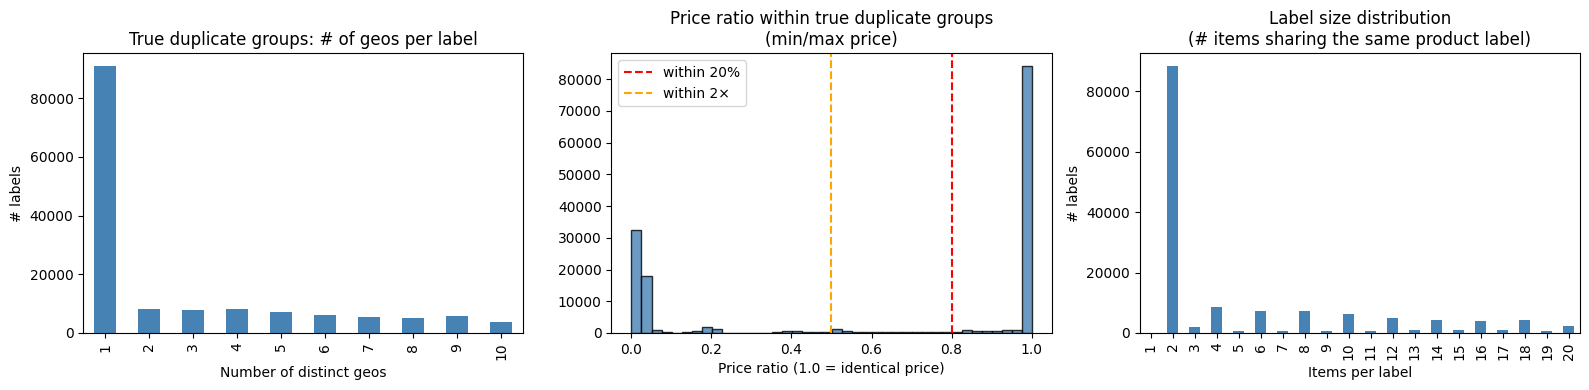

Positives same geo:           10.4%
Positives cross-geo:          89.6%
Price within 5%% in dups:     55.8%
Price >2x apart in dups:      38.3%


In [ ]:
# id_to_label = df_train.set_index('itemId')['label'].to_dict()
# id_to_dept  = df_train.set_index('itemId')['departmentIds'].fillna('').astype(str).to_dict()
# id_to_geo   = df_train.set_index('itemId')['geo'].to_dict()
# id_to_price = df_train.set_index('itemId')['price'].to_dict()

# # --- True duplicates: geo structure ---
# multi_label = df_train[df_train.label.isin(label_counts[label_counts >= 2].index)]
# geo_analysis = []
# for label, group in df_train.groupby('label'):
#     if len(group) >= 2:
#         geo_analysis.append({'n_geos': group['geo'].nunique(), 'n_items': len(group)})
# geo_df = pd.DataFrame(geo_analysis)

# # --- True duplicates: price spread ---
# price_ratios = []
# for label, group in df_train.groupby('label'):
#     if len(group) >= 2:
#         prices = group['price'].dropna()
#         if len(prices) >= 2 and prices.min() > 0:
#             price_ratios.append(prices.min() / prices.max())

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# # Plot 1: geo spread in true duplicate groups
# geo_df.n_geos.value_counts().sort_index().head(10).plot(kind='bar', ax=axes[0], color='steelblue')
# axes[0].set_title('True duplicate groups: # of geos per label')
# axes[0].set_xlabel('Number of distinct geos')
# axes[0].set_ylabel('# labels')

# # Plot 2: price ratio within true duplicate pairs
# axes[1].hist(price_ratios, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
# axes[1].axvline(0.8, color='red', linestyle='--', label='within 20%')
# axes[1].axvline(0.5, color='orange', linestyle='--', label='within 2×')
# axes[1].set_title('Price ratio within true duplicate groups\n(min/max price)')
# axes[1].set_xlabel('Price ratio (1.0 = identical price)')
# axes[1].legend()

# # Plot 3: label size distribution
# label_counts.value_counts().sort_index().head(20).plot(kind='bar', ax=axes[2], color='steelblue')
# axes[2].set_title('Label size distribution\n(# items sharing the same product label)')
# axes[2].set_xlabel('Items per label')
# axes[2].set_ylabel('# labels')

# plt.tight_layout()
# plt.show()

# print(f"Positives same geo:           {sum(1 for _,r in pos.sample(5000,random_state=0).iterrows() if id_to_geo.get(r.item_id_1)==id_to_geo.get(r.item_id_2))/5000:.1%}")
# print(f"Positives cross-geo:          {1 - sum(1 for _,r in pos.sample(5000,random_state=0).iterrows() if id_to_geo.get(r.item_id_1)==id_to_geo.get(r.item_id_2))/5000:.1%}")
# print(f"Price within 5%% in dups:     {sum(1 for x in price_ratios if x > 0.95)/len(price_ratios):.1%}")
# print(f"Price >2x apart in dups:      {sum(1 for x in price_ratios if x < 0.5)/len(price_ratios):.1%}")


In [ ]:


# rnd.seed(42)
# np.random.seed(42)

# # Pre-build lookups indexed by (dept_leaf, geo) and (dept_leaf,)
# # Use the FIRST department ID as the "leaf" category (most specific)
# df_train['dept_leaf'] = df_train['departmentIds'].fillna('').astype(str).str.split(',').str[0].str.strip()
# df_train['color_first'] = df_train['colorTagIdsString'].fillna('').astype(str).str.split(',').str[0].str.strip()

# # Index: dept_leaf + geo → list of itemIds
# dept_geo_index = defaultdict(list)
# for _, row in df_train.iterrows():
#     if row['dept_leaf']:
#         dept_geo_index[(row['dept_leaf'], row['geo'])].append(row['itemId'])

# # Index: dept_leaf (all geos) → list of itemIds  
# dept_index = defaultdict(list)
# for _, row in df_train.iterrows():
#     if row['dept_leaf']:
#         dept_index[row['dept_leaf']].append(row['itemId'])

# id_to_color  = df_train.set_index('itemId')['color_first'].to_dict()
# id_to_dept_leaf = df_train.set_index('itemId')['dept_leaf'].to_dict()

# print(f"Unique dept_leaf values:       {df_train.dept_leaf.nunique()}")
# print(f"Unique (dept_leaf, geo) keys:  {len(dept_geo_index)}")

# # Show how many items per (dept, geo) bucket — these are our hard negative pools
# bucket_sizes = sorted([len(v) for v in dept_geo_index.values()], reverse=True)
# print(f"\nTop 10 bucket sizes (dept+geo): {bucket_sizes[:10]}")
# print(f"Buckets with ≥10 items: {sum(1 for s in bucket_sizes if s >= 10)}")
# print(f"Buckets with ≥50 items: {sum(1 for s in bucket_sizes if s >= 50)}")


Unique dept_leaf values:       6
Unique (dept_leaf, geo) keys:  75

Top 10 bucket sizes (dept+geo): [130031, 58589, 58231, 48737, 44112, 44049, 43021, 40620, 39975, 31623]
Buckets with ≥10 items: 72
Buckets with ≥50 items: 63


## 4. New pair generation function

This cell contains `generate_improved_pairs()` — a drop-in replacement for whatever generated
`train_pairs_hard_negatives.csv`. Run it once, save to disk, then retrain.


In [ ]:
# def generate_improved_pairs(df, n_total=2_000_000, pos_ratio=0.20, random_state=42,
#                             tier1_frac=0.40, tier2_frac=0.25, tier3_frac=0.15):
#     """
#     Generate training pairs with structured hard negatives.

#     Negative tiers (of the 80% negative budget):
#       Tier 1 (tier1_frac): same dept_leaf + same geo + similar price  → hardest
#       Tier 2 (tier2_frac): same dept_leaf, cross-geo + similar price  → cross-geo confusers
#       Tier 3 (tier3_frac): same color + same dept_leaf                → visual confusers
#       Tier 4 (remainder):  random negatives                           → easy, prevent collapse
#     """
#     rnd.seed(random_state)
#     np.random.seed(random_state)

#     df = df.copy()
#     df['dept_leaf']   = df['departmentIds'].fillna('').astype(str).str.split(',').str[0].str.strip()
#     df['color_first'] = df['colorTagIdsString'].fillna('').astype(str).str.split(',').str[0].str.strip()

#     id_to_label  = df.set_index('itemId')['label'].to_dict()
#     id_to_price  = df.set_index('itemId')['price'].to_dict()
#     id_to_geo    = df.set_index('itemId')['geo'].to_dict()
#     id_to_dept   = df.set_index('itemId')['dept_leaf'].to_dict()
#     id_to_color  = df.set_index('itemId')['color_first'].to_dict()
#     all_ids      = df['itemId'].tolist()

#     # --- Index structures ---
#     dept_geo_idx   = defaultdict(list)   # (dept, geo)  → [itemIds]
#     dept_idx       = defaultdict(list)   # dept         → [itemIds]
#     color_dept_idx = defaultdict(list)   # (color, dept)→ [itemIds]
#     label_idx      = defaultdict(list)   # label        → [itemIds]

#     for _, row in df.iterrows():
#         iid  = row['itemId']
#         dept = row['dept_leaf']
#         geo  = row['geo']
#         col  = row['color_first']
#         lbl  = row['label']
#         if dept:
#             dept_geo_idx[(dept, geo)].append(iid)
#             dept_idx[dept].append(iid)
#         if col and dept:
#             color_dept_idx[(col, dept)].append(iid)
#         label_idx[lbl].append(iid)

#     def price_ratio(a, b):
#         pa, pb = id_to_price.get(a), id_to_price.get(b)
#         if pa and pb and pa > 0 and pb > 0:
#             return min(pa, pb) / max(pa, pb)
#         return None

#     pairs = set()

#     def add_pair(i1, i2, label):
#         key = (min(i1, i2), max(i1, i2))
#         if key not in pairs and id_to_label.get(i1) != id_to_label.get(i2) or label == 1:
#             pairs.add((key[0], key[1], label))

#     n_pos  = int(n_total * pos_ratio)
#     n_neg  = n_total - n_pos
#     n_t1   = int(n_neg * tier1_frac)
#     n_t2   = int(n_neg * tier2_frac)
#     n_t3   = int(n_neg * tier3_frac)
#     n_rand = n_neg - n_t1 - n_t2 - n_t3

#     # ── POSITIVES (same label, any geo) ──────────────────────────────────────
#     print("Generating positives...")
#     pos_pairs = []
#     multi_labels = [l for l, items in label_idx.items() if len(items) >= 2]
#     rnd.shuffle(multi_labels)
#     for lbl in multi_labels:
#         items = label_idx[lbl]
#         if len(pos_pairs) >= n_pos:
#             break
#         i1, i2 = rnd.sample(items, 2)
#         pos_pairs.append((i1, i2, 1))
#     pos_pairs = pos_pairs[:n_pos]
#     print(f"  Positives: {len(pos_pairs):,}")

#     # ── TIER 1: same dept + same geo + similar price ──────────────────────────
#     print("Generating Tier 1 negatives (same dept+geo+price)...")
#     t1_pairs = []
#     keys_t1  = [k for k, v in dept_geo_idx.items() if len(v) >= 2]
#     rnd.shuffle(keys_t1)
#     attempts = 0
#     while len(t1_pairs) < n_t1 and attempts < n_t1 * 20:
#         attempts += 1
#         key   = rnd.choice(keys_t1)
#         pool  = dept_geo_idx[key]
#         i1, i2 = rnd.sample(pool, 2)
#         if id_to_label.get(i1) == id_to_label.get(i2):
#             continue  # accidentally same label → skip
#         pr = price_ratio(i1, i2)
#         if pr is None or pr > 0.7:  # similar price OR unknown price
#             t1_pairs.append((i1, i2, 0))
#     print(f"  Tier 1: {len(t1_pairs):,}")

#     # ── TIER 2: same dept, cross-geo ─────────────────────────────────────────
#     print("Generating Tier 2 negatives (cross-geo, same dept)...")
#     t2_pairs = []
#     keys_t2  = [k for k, v in dept_idx.items() if len(v) >= 4]
#     rnd.shuffle(keys_t2)
#     attempts = 0
#     while len(t2_pairs) < n_t2 and attempts < n_t2 * 20:
#         attempts += 1
#         key  = rnd.choice(keys_t2)
#         pool = dept_idx[key]
#         i1, i2 = rnd.sample(pool, 2)
#         if id_to_label.get(i1) == id_to_label.get(i2):
#             continue
#         if id_to_geo.get(i1) == id_to_geo.get(i2):
#             continue  # want cross-geo
#         t2_pairs.append((i1, i2, 0))
#     print(f"  Tier 2: {len(t2_pairs):,}")

#     # ── TIER 3: same color + same dept ───────────────────────────────────────
#     print("Generating Tier 3 negatives (same color+dept)...")
#     t3_pairs = []
#     keys_t3  = [k for k, v in color_dept_idx.items() if len(v) >= 2]
#     rnd.shuffle(keys_t3)
#     attempts = 0
#     while len(t3_pairs) < n_t3 and attempts < n_t3 * 20:
#         attempts += 1
#         key  = rnd.choice(keys_t3)
#         pool = color_dept_idx[key]
#         i1, i2 = rnd.sample(pool, 2)
#         if id_to_label.get(i1) == id_to_label.get(i2):
#             continue
#         t3_pairs.append((i1, i2, 0))
#     print(f"  Tier 3: {len(t3_pairs):,}")

#     # ── TIER 4: random negatives ──────────────────────────────────────────────
#     print("Generating Tier 4 negatives (random)...")
#     t4_pairs = []
#     attempts = 0
#     while len(t4_pairs) < n_rand and attempts < n_rand * 5:
#         attempts += 1
#         i1, i2 = rnd.sample(all_ids, 2)
#         if id_to_label.get(i1) != id_to_label.get(i2):
#             t4_pairs.append((i1, i2, 0))
#     print(f"  Tier 4 (random): {len(t4_pairs):,}")

#     # ── Combine & shuffle ─────────────────────────────────────────────────────
#     all_pairs = pos_pairs + t1_pairs + t2_pairs + t3_pairs + t4_pairs
#     rnd.shuffle(all_pairs)

#     result = pd.DataFrame(all_pairs, columns=['item_id_1', 'item_id_2', 'is_duplicate'])
#     result = result.drop_duplicates(subset=['item_id_1', 'item_id_2']).reset_index(drop=True)
#     print(f"\nFinal: {len(result):,} pairs  "
#           f"({result.is_duplicate.mean():.1%} positive)")
#     return result

# print("Function defined. Run the next cell to generate and save.")


Function defined. Run the next cell to generate and save.


In [ ]:
# ── Item-level split: hold out 20% of LABELS for validation ──────────────────
# The key fix: if the same items can appear in both train and val pairs,
# the model memorises item embeddings and val F1 inflates to ~0.99.
# By splitting on LABELS (not rows), no item from a val label ever appears
# in a training pair → honest generalisation signal.
from collections import defaultdict
import random as rnd

rnd.seed(0)
all_labels = df_train['label'].unique().tolist()
rnd.shuffle(all_labels)

val_label_set   = set(all_labels[:int(0.20 * len(all_labels))])
train_label_set = set(all_labels[int(0.20 * len(all_labels)):])

df_train_split = df_train[df_train['label'].isin(train_label_set)].reset_index(drop=True)
df_val_split   = df_train[df_train['label'].isin(val_label_set)].reset_index(drop=True)

print(f"Train items (80% of labels): {len(df_train_split):,}  |  {len(train_label_set):,} labels")
print(f"Val   items (20% of labels): {len(df_val_split):,}    |  {len(val_label_set):,} labels")
print(f"Item overlap between splits: "
      f"{len(set(df_train_split.itemId) & set(df_val_split.itemId))}  (must be 0)")

Train items (80% of labels): 740,960  |  121,896 labels
Val   items (20% of labels): 187,274    |  30,474 labels
Item overlap between splits: 0  (must be 0)


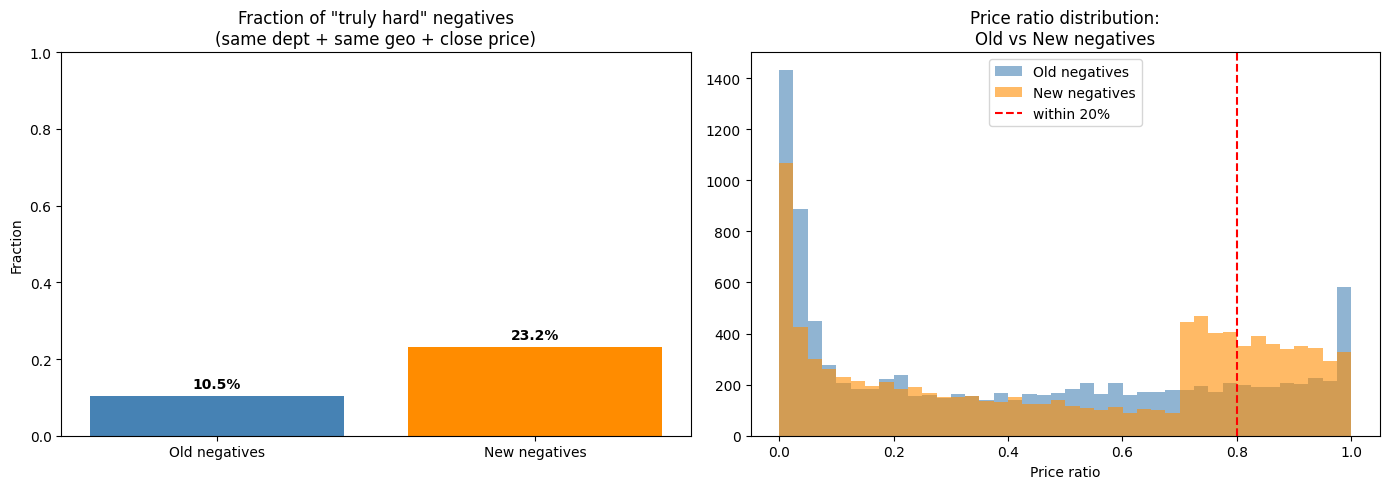

Old negatives — same dept: 77.4%, same geo: 26.9%, close price: 20.1%
New negatives — same dept: 86.3%, same geo: 46.6%, close price: 27.6%


In [ ]:
# # Visualise the new negatives vs old negatives
# train_new = pd.read_csv("train_pairs_improved.csv")
# neg_new = train_new[train_new.is_duplicate == 0].sample(10_000, random_state=42)
# neg_new['dept1']  = neg_new.item_id_1.map(id_to_dept_leaf)
# neg_new['dept2']  = neg_new.item_id_2.map(id_to_dept_leaf)
# neg_new['geo1']   = neg_new.item_id_1.map(id_to_geo)
# neg_new['geo2']   = neg_new.item_id_2.map(id_to_geo)
# neg_new['price1'] = neg_new.item_id_1.map(id_to_price)
# neg_new['price2'] = neg_new.item_id_2.map(id_to_price)
# neg_new['same_dept'] = neg_new.apply(lambda r: r.dept1 == r.dept2, axis=1)
# neg_new['same_geo']  = neg_new.geo1 == neg_new.geo2
# neg_new['price_ratio'] = neg_new.apply(
#     lambda r: min(r.price1, r.price2)/max(r.price1, r.price2)
#              if pd.notna(r.price1) and pd.notna(r.price2) and max(r.price1, r.price2) > 0
#              else np.nan, axis=1)
# neg_new['close_price'] = neg_new.price_ratio > 0.8

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Side-by-side: truly hard fraction
# old_truly_hard = (neg_sample.same_dept & neg_sample.same_geo & neg_sample.close_price).mean()
# new_truly_hard = (neg_new.same_dept & neg_new.same_geo & neg_new.close_price).mean()

# axes[0].bar(['Old negatives', 'New negatives'],
#             [old_truly_hard, new_truly_hard],
#             color=['steelblue', 'darkorange'])
# axes[0].set_title('Fraction of "truly hard" negatives\n(same dept + same geo + close price)')
# axes[0].set_ylabel('Fraction')
# axes[0].set_ylim(0, 1)
# for i, v in enumerate([old_truly_hard, new_truly_hard]):
#     axes[0].text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')

# # Price ratio comparison
# axes[1].hist(neg_sample.price_ratio.dropna(), bins=40, alpha=0.6, label='Old negatives', color='steelblue')
# axes[1].hist(neg_new.price_ratio.dropna(),   bins=40, alpha=0.6, label='New negatives', color='darkorange')
# axes[1].axvline(0.8, color='red', linestyle='--', label='within 20%')
# axes[1].set_title('Price ratio distribution:\nOld vs New negatives')
# axes[1].set_xlabel('Price ratio')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

# print(f"Old negatives — same dept: {neg_sample.same_dept.mean():.1%}, same geo: {neg_sample.same_geo.mean():.1%}, close price: {neg_sample.close_price.mean():.1%}")
# print(f"New negatives — same dept: {neg_new.same_dept.mean():.1%}, same geo: {neg_new.same_geo.mean():.1%}, close price: {neg_new.close_price.mean():.1%}")


# Hard Negative Mining v2: CLIP Image + Text Embedding Similarity

**Problem:** Current negatives are hard based on *metadata* (dept, geo, price) but not on *embedding similarity*.  
The model fails on items whose embeddings are close but belong to different labels — same-looking / same-sounding, different products.

**Solution:** Mine pairs where the **combined** (image + text) cosine similarity is high but `label_A ≠ label_B`.

**Combined similarity** = mean of:
- `cosine_sim(image_emb_A, image_emb_B)` — visual similarity  
- `cosine_sim(text_emb_A, text_emb_B)` — title+description semantic similarity

Items that score high on **both** are the true confusers for the siamese model.

In [ ]:

import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

# ── Load CLIP image embeddings ────────────────────────────────────────────────
print("Loading CLIP image embeddings...")
clip_emb_raw = torch.load("clip_embeddings.pt", map_location="cpu")
sample_key = next(iter(clip_emb_raw))
print(f"  {len(clip_emb_raw):,} image embeddings  |  key type: {type(sample_key).__name__}  |  dim: {clip_emb_raw[sample_key].shape[0]}")

# ── Load text embeddings ──────────────────────────────────────────────────────
print("Loading text embeddings...")
text_emb_raw = torch.load("text_embeddings.pt", map_location="cpu")
sample_key_t = next(iter(text_emb_raw))
print(f"  {len(text_emb_raw):,} text embeddings   |  key type: {type(sample_key_t).__name__}  |  dim: {text_emb_raw[sample_key_t].shape[0]}")

# ── Filter to train split items that have BOTH embeddings ─────────────────────
train_ids_int = df_train_split['itemId'].tolist()

def _get_img_emb(item_id):
    v = clip_emb_raw.get(item_id)
    if v is None:
        v = clip_emb_raw.get(str(item_id))
    return v

def _get_txt_emb(item_id):
    v = text_emb_raw.get(str(item_id))
    if v is None:
        v = text_emb_raw.get(item_id)
    return v

train_ids_with_emb = [
    iid for iid in train_ids_int
    if _get_img_emb(iid) is not None and _get_txt_emb(iid) is not None
]
print(f"\n  Train items with both embeddings: {len(train_ids_with_emb):,} / {len(train_ids_int):,}")

# ── Build individual normalised matrices ──────────────────────────────────────
img_matrix  = torch.stack([_get_img_emb(iid) for iid in train_ids_with_emb]).float()
img_matrix  = F.normalize(img_matrix, dim=1)   # (N, 768)

txt_matrix  = torch.stack([_get_txt_emb(iid) for iid in train_ids_with_emb]).float()
txt_matrix  = F.normalize(txt_matrix, dim=1)   # (N, 512)

print(f"  Image matrix : {img_matrix.shape}")
print(f"  Text  matrix : {txt_matrix.shape}")

# ── Label lookup ──────────────────────────────────────────────────────────────
id_to_label_train = df_train_split.set_index('itemId')['label'].to_dict()
print(f"  Label dict size: {len(id_to_label_train):,}")


Loading CLIP image embeddings...
  928,234 image embeddings  |  key type: str  |  dim: 768
Loading text embeddings...
  1,128,069 text embeddings   |  key type: str  |  dim: 512

  Train items with both embeddings: 740,960 / 740,960
  Image matrix : torch.Size([740960, 768])
  Text  matrix : torch.Size([740960, 512])
  Label dict size: 740,960


In [ ]:
def mine_embedding_hard_negatives(
    img_matrix,          # (N, Di) float32 normalised tensor — CLIP image
    txt_matrix,          # (N, Dt) float32 normalised tensor — multilingual text
    item_ids,            # list of N item IDs (ints)
    id_to_label,         # dict item_id -> label
    n_pairs   = 7000000, # how many hard negative pairs to return
    sim_lo    = 0.9,    # min combined cosine similarity  (visually+textually similar)
    sim_hi    = 1,    # max combined cosine similarity  (avoid near-exact duplicates)
    batch_size= 1_000,   # rows per matmul chunk
    random_state = 42,
):
    """
    Mine pairs with high combined (image + text) cosine similarity but different product labels.

    Strategy:
    - Shuffle items, process in batches of `batch_size`.
    - For each batch compute cosine sim against the NEXT batch (avoids self-pairs).
    - Combined similarity = mean of image cosine sim + text cosine sim.
    - Collect (i,j) pairs where combined_sim ∈ [sim_lo, sim_hi] and label_i ≠ label_j.
    - Stop early when n_pairs collected.
    """
    rng = np.random.default_rng(random_state)
    N   = len(item_ids)
    order = rng.permutation(N)
    item_ids_arr = np.array(item_ids)

    hard_pairs = []
    n_batches  = (N + batch_size - 1) // batch_size

    pbar = tqdm(total=n_pairs, desc="Mining image+text hard-neg pairs", unit="pair")

    for bi in range(n_batches):
        if len(hard_pairs) >= n_pairs:
            break
        # anchor batch
        a_idx  = order[bi * batch_size : (bi + 1) * batch_size]
        a_img  = img_matrix[a_idx]           # (Ba, Di)
        a_txt  = txt_matrix[a_idx]           # (Ba, Dt)
        a_ids  = item_ids_arr[a_idx]

        # compare against the rest of the dataset (avoid i==j)
        rest_idx = np.concatenate([order[:bi * batch_size], order[(bi + 1) * batch_size:]])
        # sub-sample rest to keep matmul manageable
        if len(rest_idx) > 8_000:
            rest_idx = rng.choice(rest_idx, 8_000, replace=False)

        if len(rest_idx) == 0:
            continue

        r_img = img_matrix[rest_idx]         # (Br, Di)
        r_txt = txt_matrix[rest_idx]         # (Br, Dt)
        r_ids = item_ids_arr[rest_idx]

        # per-modality cosine similarity (already normalised): (Ba, Br)
        img_sim = torch.mm(a_img, r_img.T).numpy()  # float32 numpy
        txt_sim = torch.mm(a_txt, r_txt.T).numpy()  # float32 numpy

        # combined score = average of both modalities
        combined_sim = (img_sim + txt_sim) * 0.5

        # find positions where combined_sim in range
        a_pos, r_pos = np.where((combined_sim >= sim_lo) & (combined_sim <= sim_hi))

        found_before = len(hard_pairs)
        for ai, ri in zip(a_pos, r_pos):
            id1 = int(a_ids[ai])
            id2 = int(r_ids[ri])
            l1  = id_to_label.get(id1)
            l2  = id_to_label.get(id2)
            if l1 is not None and l2 is not None and l1 != l2:
                hard_pairs.append((id1, id2, 0))

        pbar.update(len(hard_pairs) - found_before)

        if len(hard_pairs) >= n_pairs:
            break

    pbar.close()

    df_hard = pd.DataFrame(hard_pairs[:n_pairs], columns=['item_id_1', 'item_id_2', 'is_duplicate'])
    # deduplicate
    df_hard = df_hard.drop_duplicates(subset=['item_id_1', 'item_id_2']).reset_index(drop=True)
    print(f"\nMined {len(df_hard):,} unique embedding-based hard negatives (image+text combined)")
    return df_hard


# ── Run the miner ─────────────────────────────────────────────────────────────
hard_negs_emb = mine_embedding_hard_negatives(
    img_matrix,
    txt_matrix,
    train_ids_with_emb,
    id_to_label_train,
    n_pairs    = 1_100_000,
    sim_lo     = 0.8,
    sim_hi     = 1,
    batch_size = 1_000,
    random_state = 42,
)
print(hard_negs_emb.head())


Mining image+text hard-neg pairs:   0%|          | 0/1100000 [00:00<?, ?pair/s]


Mined 1,100,000 unique embedding-based hard negatives (image+text combined)
   item_id_1  item_id_2  is_duplicate
0      47546     653307             0
1      47546    1053125             0
2      47546      98578             0
3      47546     202809             0
4      47546     234031             0


In [ ]:
import pandas as pd

# ── Load existing train pairs ────────────────────────────────────────────────
train_existing = pd.read_csv("train_pairs_improved.csv")
print(f"Existing train pairs : {len(train_existing):,}")
print(f"  Positive rate      : {train_existing.is_duplicate.mean():.1%}")

pos_pairs = train_existing[train_existing.is_duplicate == 1].copy()
neg_pairs = train_existing[train_existing.is_duplicate == 0].copy()
print(f"  Positives: {len(pos_pairs):,}   Negatives: {len(neg_pairs):,}")

# ── How many embedding hard-neg pairs do we have? ───────────────────────────
n_hard   = len(hard_negs_emb)
n_to_drop = min(n_hard, len(neg_pairs))   # replace this many random negatives

# Drop that many random negatives (the "Tier 4" ones are at the tail after
# generate_improved_pairs shuffles, but here we just random-drop any negatives)
neg_keep = neg_pairs.sample(n=len(neg_pairs) - n_to_drop, random_state=42)
print(f"\nDropping {n_to_drop:,} metadata negatives")
print(f"Adding   {n_hard:,} embedding hard negatives")

# ── Concat and shuffle ───────────────────────────────────────────────────────
train_final = pd.concat([pos_pairs, neg_keep, hard_negs_emb], ignore_index=True)
train_final = train_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal train pairs    : {len(train_final):,}")
print(f"  Positive rate      : {train_final.is_duplicate.mean():.1%}")

# ── Save ─────────────────────────────────────────────────────────────────────
train_final.to_csv("train_pairs_improved.csv", index=False)
print("Saved → train_pairs_improved.csv  ✓")

# Val pairs unchanged (they come from the held-out 20% label split and
# there are no CLIP embeddings for val items from that split).
print("Val pairs unchanged  → val_pairs_improved.csv")


Existing train pairs : 1,479,942
  Positive rate      : 8.2%
  Positives: 121,889   Negatives: 1,358,053

Dropping 1,100,000 metadata negatives
Adding   1,100,000 embedding hard negatives

Final train pairs    : 1,479,942
  Positive rate      : 8.2%
Saved → train_pairs_improved.csv  ✓
Val pairs unchanged  → val_pairs_improved.csv
